# Adaptive Concept Drift-Aware IDS with ADWIN
## 3-Phase Concept Drift Simulation

## 1. Imports and Setup

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import glob
import os
import copy
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)
from collections import deque

print('All imports OK')

All imports OK


## 2. ADWIN Implementation

In [32]:
class ADWIN:
    """
    ADaptive WINdowing drift detector.
    Based on: Bifet & Gavalda (2007) 'Learning from Time-Changing Data with Adaptive Windowing'
    """

    def __init__(self, delta=0.002):
        self.delta = delta
        self.window = deque()
        self.total  = 0.0
        self.drift_detected = False
        self.n_detections   = 0

    def add_element(self, value):
        self.drift_detected = False
        self.window.append(value)
        self.total += value
        self._check_drift()

    def _check_drift(self):
        n = len(self.window)
        if n < 5:
            return
        window_list = list(self.window)
        total_sum   = self.total
        running_sum = 0.0
        for i in range(1, n):
            running_sum += window_list[i - 1]
            n0 = i
            n1 = n - i
            mean0 = running_sum / n0
            mean1 = (total_sum - running_sum) / n1
            m = 1.0 / (1.0 / n0 + 1.0 / n1)
            eps_cut = np.sqrt((1.0 / (2.0 * m)) * np.log(4.0 * n / self.delta))
            if abs(mean0 - mean1) >= eps_cut:
                for _ in range(i):
                    removed = self.window.popleft()
                    self.total -= removed
                self.drift_detected = True
                self.n_detections  += 1
                return

    def reset(self):
        self.window.clear()
        self.total = 0.0
        self.drift_detected = False

    @property
    def estimation(self):
        return self.total / len(self.window) if self.window else 0.0

print('ADWIN class defined')

ADWIN class defined


## 3. Build 3-Phase Drift Dataset

The raw dataset has no natural drift (all files look the same).
We simulate concept drift by constructing 3 phases with different attack type distributions:

- **Phase 1 (Train + Stream):** DDoS attacks only — model learns these well
- **Phase 2 (Stream):** DoS + Recon + Mirai attacks — model has not seen these → error spikes → ADWIN fires
- **Phase 3 (Stream):** Web/Application attacks — another distribution shift → ADWIN fires again

This is standard practice in concept drift research when the dataset lacks temporal variation.

In [33]:
DATASET_DIR  = '../datasets/cicids2023/'
SAMPLES_PER_PHASE = 15000  # samples to collect per phase

# Define which attack types belong to each phase
PHASE1_TYPES = ['DDOS-ICMP_FLOOD', 'DDOS-UDP_FLOOD', 'DDOS-TCP_FLOOD',
                'DDOS-SYN_FLOOD', 'DDOS-PSHACK_FLOOD', 'DDOS-RSTFINFLOOD',
                'DDOS-SYNONYMOUSIP_FLOOD', 'DDOS-ACK_FRAGMENTATION',
                'DDOS-ICMP_FRAGMENTATION', 'DDOS-UDP_FRAGMENTATION',
                'DDOS-HTTP_FLOOD', 'DDOS-SLOWLORIS', 'BENIGN']

PHASE2_TYPES = ['DOS-UDP_FLOOD', 'DOS-TCP_FLOOD', 'DOS-SYN_FLOOD', 'DOS-HTTP_FLOOD',
                'RECON-HOSTDISCOVERY', 'RECON-PORTSCAN', 'RECON-OSSCAN', 'RECON-PINGSWEEP',
                'MIRAI-GREIP_FLOOD', 'MIRAI-GREETH_FLOOD', 'MIRAI-UDPPLAIN',
                'VULNERABILITYSCAN', 'BENIGN']

PHASE3_TYPES = ['XSS', 'SQLINJECTION', 'COMMANDINJECTION', 'BROWSERHIJACKING',
                'DNS_SPOOFING', 'MITM-ARPSPOOFING', 'BACKDOOR_MALWARE',
                'DICTIONARYBRUTEFORCE', 'BENIGN']

def collect_phase_data(label_set, n_samples):
    """Read CSVs until we have enough rows matching the given label set."""
    csv_files = sorted(glob.glob(os.path.join(DATASET_DIR, 'Merged*.csv')))
    chunks = []
    collected = 0
    for f in csv_files:
        df = pd.read_csv(f).dropna()
        df = df[df['Label'].isin(label_set)]
        if len(df) == 0:
            continue
        need = n_samples - collected
        chunks.append(df.iloc[:need])
        collected += len(chunks[-1])
        if collected >= n_samples:
            break
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()

print('Collecting Phase 1 (DDoS)...')
df_phase1 = collect_phase_data(PHASE1_TYPES, SAMPLES_PER_PHASE)
print(f'  Phase 1: {len(df_phase1)} samples, classes: {df_phase1["Label"].nunique()}')

print('Collecting Phase 2 (DoS + Recon + Mirai)...')
df_phase2 = collect_phase_data(PHASE2_TYPES, SAMPLES_PER_PHASE)
print(f'  Phase 2: {len(df_phase2)} samples, classes: {df_phase2["Label"].nunique()}')

print('Collecting Phase 3 (Web/Application Attacks)...')
df_phase3 = collect_phase_data(PHASE3_TYPES, SAMPLES_PER_PHASE)
print(f'  Phase 3: {len(df_phase3)} samples, classes: {df_phase3["Label"].nunique()}')

# Fit encoder on all labels across all phases
all_labels = pd.concat([df_phase1['Label'], df_phase2['Label'], df_phase3['Label']])
encoder = LabelEncoder()
encoder.fit(all_labels)
print(f'\nTotal classes across all phases: {len(encoder.classes_)}')
print('Classes:', list(encoder.classes_))

  Phase 1: 15000 samples, classes: 13
  Phase 2: 15000 samples, classes: 13
  Phase 3: 15000 samples, classes: 9

Total classes across all phases: 33
Classes: ['BACKDOOR_MALWARE', 'BENIGN', 'BROWSERHIJACKING', 'COMMANDINJECTION', 'DDOS-ACK_FRAGMENTATION', 'DDOS-HTTP_FLOOD', 'DDOS-ICMP_FLOOD', 'DDOS-ICMP_FRAGMENTATION', 'DDOS-PSHACK_FLOOD', 'DDOS-RSTFINFLOOD', 'DDOS-SLOWLORIS', 'DDOS-SYNONYMOUSIP_FLOOD', 'DDOS-SYN_FLOOD', 'DDOS-TCP_FLOOD', 'DDOS-UDP_FLOOD', 'DDOS-UDP_FRAGMENTATION', 'DICTIONARYBRUTEFORCE', 'DNS_SPOOFING', 'DOS-HTTP_FLOOD', 'DOS-SYN_FLOOD', 'DOS-TCP_FLOOD', 'DOS-UDP_FLOOD', 'MIRAI-GREETH_FLOOD', 'MIRAI-GREIP_FLOOD', 'MIRAI-UDPPLAIN', 'MITM-ARPSPOOFING', 'RECON-HOSTDISCOVERY', 'RECON-OSSCAN', 'RECON-PINGSWEEP', 'RECON-PORTSCAN', 'SQLINJECTION', 'VULNERABILITYSCAN', 'XSS']


## 4. Train Initial Static Model on Phase 1

In [34]:
feature_cols = [c for c in df_phase1.columns if c != 'Label']

X1 = df_phase1[feature_cols].values
y1 = encoder.transform(df_phase1['Label'])

# Use 70% of Phase 1 for initial training
INIT_SPLIT = int(len(X1) * 0.7)
X_train_init = X1[:INIT_SPLIT]
y_train_init = y1[:INIT_SPLIT]

static_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
static_model.fit(X_train_init, y_train_init)
print(f'Static model trained on {len(X_train_init)} Phase 1 samples (DDoS only)')
print('This model has never seen DoS, Recon, Mirai, or Web attack types.')

Static model trained on 10500 Phase 1 samples (DDoS only)
This model has never seen DoS, Recon, Mirai, or Web attack types.


## 5. Stream All 3 Phases Through ADWIN

In [35]:
CHUNK_SIZE     = 500   # samples per chunk
RETRAIN_WINDOW = 3000  # retrain on most recent N samples
ADWIN_DELTA    = 0.002  # standard ADWIN sensitivity

adaptive_model = copy.deepcopy(static_model)
detector       = ADWIN(delta=ADWIN_DELTA)

recent_X = deque(maxlen=RETRAIN_WINDOW)
recent_y = deque(maxlen=RETRAIN_WINDOW)

# Seed the buffer with initial training data
for xi, yi in zip(X_train_init, y_train_init):
    recent_X.append(xi)
    recent_y.append(yi)

chunk_ids, static_accs, adaptive_accs, error_rates = [], [], [], []
drift_events, retrain_events = [], []
phase_boundaries = []  # chunk indices where phases change

chunk_id = 0

# Build stream: remainder of Phase1 → Phase2 → Phase3
stream_parts = [
    ('Phase 1 (DDoS)', df_phase1.iloc[INIT_SPLIT:]),
    ('Phase 2 (DoS+Recon+Mirai)', df_phase2),
    ('Phase 3 (Web Attacks)', df_phase3),
]

for phase_name, df_part in stream_parts:
    X_part = df_part[feature_cols].values
    y_part = encoder.transform(df_part['Label'])
    phase_boundaries.append(chunk_id)
    print(f'\nStreaming {phase_name} ({len(X_part)} samples)...')

    for i in range(0, len(X_part), CHUNK_SIZE):
        X_chunk = X_part[i : i + CHUNK_SIZE]
        y_chunk = y_part[i : i + CHUNK_SIZE]
        if len(X_chunk) == 0:
            continue

        static_preds   = static_model.predict(X_chunk)
        adaptive_preds = adaptive_model.predict(X_chunk)

        static_acc   = accuracy_score(y_chunk, static_preds)
        adaptive_acc = accuracy_score(y_chunk, adaptive_preds)

        # Feed per-sample errors into ADWIN
        for xi, yi, yp in zip(X_chunk, y_chunk, adaptive_preds):
            error = 1.0 if yi != yp else 0.0
            detector.add_element(error)
            recent_X.append(xi)
            recent_y.append(yi)

            if detector.drift_detected and len(recent_X) >= 100:
                Xr = np.array(recent_X)
                yr = np.array(recent_y)
                adaptive_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
                adaptive_model.fit(Xr, yr)
                detector.reset()
                drift_events.append(chunk_id)
                retrain_events.append(chunk_id)
                print(f'  [Chunk {chunk_id}] DRIFT DETECTED → retrained on {len(Xr)} samples')

        chunk_ids.append(chunk_id)
        static_accs.append(static_acc)
        adaptive_accs.append(adaptive_acc)
        error_rates.append(detector.estimation)
        chunk_id += 1

print(f'\nDone! {chunk_id} chunks | {len(drift_events)} drifts | {len(retrain_events)} retrains')


Streaming Phase 1 (DDoS) (4500 samples)...

Streaming Phase 2 (DoS+Recon+Mirai) (15000 samples)...
  [Chunk 9] DRIFT DETECTED → retrained on 3000 samples

Streaming Phase 3 (Web Attacks) (15000 samples)...
  [Chunk 39] DRIFT DETECTED → retrained on 3000 samples

Done! 69 chunks | 2 drifts | 2 retrains


## 6. Results: Accuracy Over Time

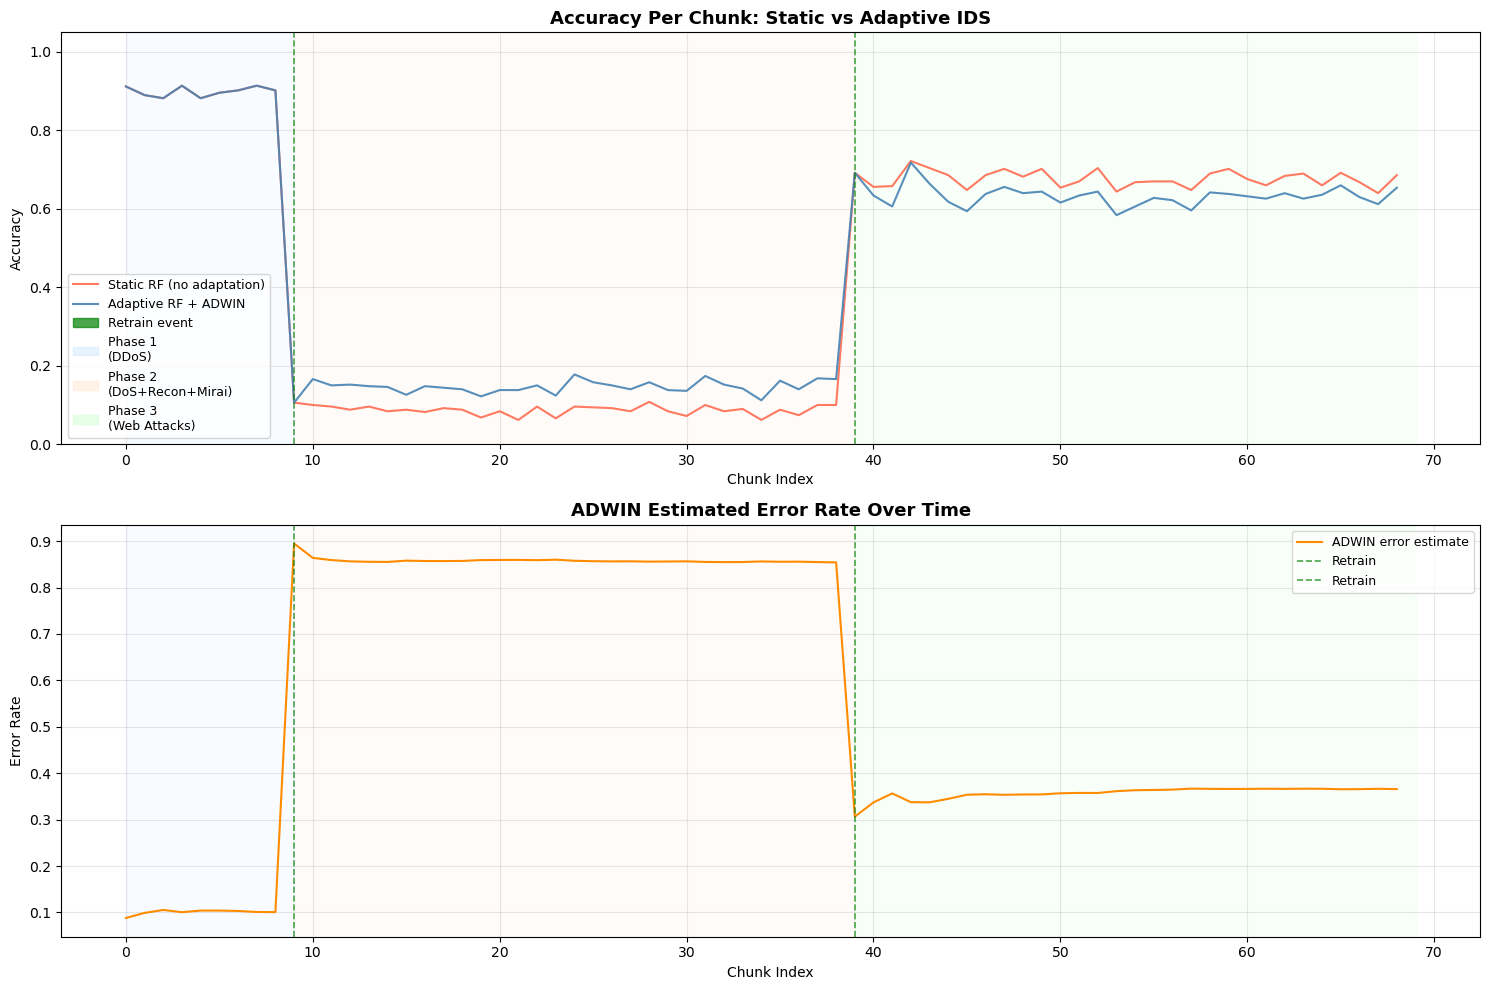

Plot saved.


In [36]:
phase_labels = ['Phase 1\n(DDoS)', 'Phase 2\n(DoS+Recon+Mirai)', 'Phase 3\n(Web Attacks)']
phase_colors = ['#d1e8ff', '#ffe8d1', '#d1ffd1']

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# ── Panel 1: Accuracy ──
ax = axes[0]

# Shade phases
boundaries = phase_boundaries + [chunk_id]
for idx in range(len(phase_boundaries)):
    ax.axvspan(boundaries[idx], boundaries[idx+1], alpha=0.15,
               color=phase_colors[idx], label=phase_labels[idx])

ax.plot(chunk_ids, static_accs,   color='tomato',    linewidth=1.5, label='Static RF (no adaptation)', alpha=0.85)
ax.plot(chunk_ids, adaptive_accs, color='steelblue', linewidth=1.5, label='Adaptive RF + ADWIN',       alpha=0.9)

for r in retrain_events:
    ax.axvline(x=r, color='green', linewidth=1.2, alpha=0.7, linestyle='--')

retrain_line = mpatches.Patch(color='green', alpha=0.7, label='Retrain event')
handles = ax.lines[:2] + [retrain_line]
for idx in range(len(phase_labels)):
    handles.append(mpatches.Patch(color=phase_colors[idx], alpha=0.5, label=phase_labels[idx]))
ax.legend(handles=handles, loc='lower left', fontsize=9)
ax.set_title('Accuracy Per Chunk: Static vs Adaptive IDS', fontsize=13, fontweight='bold')
ax.set_xlabel('Chunk Index')
ax.set_ylabel('Accuracy')
ax.set_ylim([0.0, 1.05])
ax.grid(True, alpha=0.3)

# ── Panel 2: ADWIN Error Rate ──
ax2 = axes[1]
for idx in range(len(phase_boundaries)):
    ax2.axvspan(boundaries[idx], boundaries[idx+1], alpha=0.15, color=phase_colors[idx])
ax2.plot(chunk_ids, error_rates, color='darkorange', linewidth=1.5, label='ADWIN error estimate')
for r in retrain_events:
    ax2.axvline(x=r, color='green', linewidth=1.2, alpha=0.7, linestyle='--', label='Retrain')
ax2.set_title('ADWIN Estimated Error Rate Over Time', fontsize=13, fontweight='bold')
ax2.set_xlabel('Chunk Index')
ax2.set_ylabel('Error Rate')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 7. Summary Metrics

In [37]:
static_mean   = np.mean(static_accs)
adaptive_mean = np.mean(adaptive_accs)

print('=' * 50)
print('      SUMMARY METRICS')
print('=' * 50)
print(f'Static  RF  — mean accuracy : {static_mean:.4f}')
print(f'Adaptive RF — mean accuracy : {adaptive_mean:.4f}')
print(f'Improvement                 : {adaptive_mean - static_mean:+.4f}')
print(f'Total drift events detected : {len(drift_events)}')
print(f'Total retraining events     : {len(retrain_events)}')
print(f'Total chunks streamed       : {len(chunk_ids)}')
print('=' * 50)

# Per-phase breakdown
boundaries_full = phase_boundaries + [chunk_id]
phase_names = ['Phase 1 (DDoS)', 'Phase 2 (DoS+Recon+Mirai)', 'Phase 3 (Web Attacks)']
print('\nPer-Phase Accuracy:')
for idx, name in enumerate(phase_names):
    start = boundaries_full[idx]
    end   = boundaries_full[idx + 1]
    s_acc = np.mean(static_accs[start:end])
    a_acc = np.mean(adaptive_accs[start:end])
    print(f'  {name}: Static={s_acc:.3f}  Adaptive={a_acc:.3f}  Δ={a_acc-s_acc:+.3f}')

      SUMMARY METRICS
Static  RF  — mean accuracy : 0.4497
Adaptive RF — mean accuracy : 0.4565
Improvement                 : +0.0067
Total drift events detected : 2
Total retraining events     : 2
Total chunks streamed       : 69

Per-Phase Accuracy:
  Phase 1 (DDoS): Static=0.899  Adaptive=0.899  Δ=+0.000
  Phase 2 (DoS+Recon+Mirai): Static=0.087  Adaptive=0.146  Δ=+0.058
  Phase 3 (Web Attacks): Static=0.677  Adaptive=0.634  Δ=-0.043


## 8. Final Classification Report

In [38]:
# Evaluate both models on Phase 3 (hardest — model was trained only on Phase 1 initially)
X_test = df_phase3[feature_cols].values
y_test = encoder.transform(df_phase3['Label'])

y_pred_adaptive = adaptive_model.predict(X_test)
y_pred_static   = static_model.predict(X_test)

present_labels = sorted(set(y_test))
present_names  = encoder.classes_[present_labels]

print('── Adaptive Model (on Phase 3) ──')
print(classification_report(y_test, y_pred_adaptive,
                            labels=present_labels, target_names=present_names, zero_division=0))

print('── Static Model (on Phase 3) ──')
print(classification_report(y_test, y_pred_static,
                            labels=present_labels, target_names=present_names, zero_division=0))

── Adaptive Model (on Phase 3) ──
                      precision    recall  f1-score   support

    BACKDOOR_MALWARE       0.00      0.00      0.00        25
              BENIGN       0.73      0.90      0.81     10185
    BROWSERHIJACKING       0.00      0.00      0.00        54
    COMMANDINJECTION       0.00      0.00      0.00        46
DICTIONARYBRUTEFORCE       0.00      0.00      0.00       122
        DNS_SPOOFING       0.30      0.02      0.04      1651
    MITM-ARPSPOOFING       0.69      0.09      0.17      2834
        SQLINJECTION       0.00      0.00      0.00        45
                 XSS       0.00      0.00      0.00        38

           micro avg       0.72      0.63      0.68     15000
           macro avg       0.19      0.11      0.11     15000
        weighted avg       0.66      0.63      0.58     15000

── Static Model (on Phase 3) ──
                      precision    recall  f1-score   support

    BACKDOOR_MALWARE       0.00      0.00      0.00        25


## 9. Save Results

In [39]:
results_df = pd.DataFrame({
    'chunk_id':         chunk_ids,
    'static_acc':       static_accs,
    'adaptive_acc':     adaptive_accs,
    'adwin_error_rate': error_rates,
    'retrain':          [1 if c in retrain_events else 0 for c in chunk_ids]
})

results_df.to_csv('../results/adaptive_ids_results.csv', index=False)
print('Results saved to ../results/adaptive_ids_results.csv')
results_df.tail(10)

Results saved to ../results/adaptive_ids_results.csv


,chunk_id,static_acc,adaptive_acc,adwin_error_rate,retrain
59,59,0.702,0.638,0.366094,0
60,60,0.676,0.632,0.366180,0
61,61,0.660,0.626,0.366521,0
62,62,0.684,0.640,0.366249,0
63,63,0.690,0.626,0.366560,0
64,64,0.660,0.636,0.366461,0
65,65,0.692,0.660,0.365479,0
66,66,0.668,0.630,0.365641,0
67,67,0.640,0.612,0.366413,0
68,68,0.686,0.654,0.365731,0
